# MLPR Lab 12
### Proshita Agarwal

Step-1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

Step-2

In [3]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/Fertility_Diagnosis.txt'
data = np.genfromtxt(path, delimiter=',')
X = data[:, :-1]   # first 9 features
y = data[:, -1].reshape(-1, 1)  # target
y = (y - y.min()) / (y.max() - y.min())

# Train-test split (80-20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

Mounted at /content/drive


Step-3

In [6]:
input_size = X_train.shape[1]
output_size = 1
train_errors = []
test_errors = []
tolerance = 0.05
alpha = 0.001

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

Step-4,5,6,7,8

In [7]:
for hidden_neurons in range(1, 10):
    print(f"\n--- Hidden Neurons: {hidden_neurons} ---")

    # Initialize weights
    W1 = np.random.uniform(-1, 1, (input_size, hidden_neurons))
    W2 = np.random.uniform(-1, 1, (hidden_neurons, output_size))

    # Training loop
    for epoch in range(1, 1000001):

        # Forward pass
        L0 = X_train
        L1 = sigmoid(np.dot(L0, W1))
        L2 = sigmoid(np.dot(L1, W2))

        # Error
        error = y_train - L2
        mse = mean_squared_error(y_train, L2)

        # Step 6: Check convergence
        if mse < tolerance:
            print(f"Stopped at epoch {epoch} with MSE: {mse:.5f}")
            break

        # Backpropagation
        dL2 = error * sigmoid_derivative(L2)
        dL1 = dL2.dot(W2.T) * sigmoid_derivative(L1)

        # Update weights
        W2 += alpha * L1.T.dot(dL2)
        W1 += alpha * L0.T.dot(dL1)

        # Debug print
        if epoch % 200000 == 0:
            print(f"Epoch {epoch}, MSE: {mse:.5f}")

    # Step 7: Training evaluation
    L1_train = sigmoid(np.dot(X_train, W1))
    L2_train = sigmoid(np.dot(L1_train, W2))
    train_mse = mean_squared_error(y_train, L2_train)
    train_errors.append(train_mse)
    print(f"Final Training MSE: {train_mse:.5f}")

    # Step 8: Testing evaluation
    L1_test = sigmoid(np.dot(X_test, W1))
    L2_test = sigmoid(np.dot(L1_test, W2))
    test_mse = mean_squared_error(y_test, L2_test)
    test_errors.append(test_mse)
    print(f"Final Testing MSE: {test_mse:.5f}")


--- Hidden Neurons: 1 ---
Epoch 200000, MSE: 0.07901
Epoch 400000, MSE: 0.07699
Epoch 600000, MSE: 0.07567
Epoch 800000, MSE: 0.07465
Epoch 1000000, MSE: 0.07387
Final Training MSE: 0.07387
Final Testing MSE: 0.09938

--- Hidden Neurons: 2 ---
Stopped at epoch 149525 with MSE: 0.05000
Final Training MSE: 0.05000
Final Testing MSE: 0.11212

--- Hidden Neurons: 3 ---
Stopped at epoch 101350 with MSE: 0.05000
Final Training MSE: 0.05000
Final Testing MSE: 0.11182

--- Hidden Neurons: 4 ---
Stopped at epoch 78702 with MSE: 0.05000
Final Training MSE: 0.05000
Final Testing MSE: 0.10650

--- Hidden Neurons: 5 ---
Stopped at epoch 88158 with MSE: 0.05000
Final Training MSE: 0.05000
Final Testing MSE: 0.10825

--- Hidden Neurons: 6 ---
Stopped at epoch 93447 with MSE: 0.05000
Final Training MSE: 0.05000
Final Testing MSE: 0.11254

--- Hidden Neurons: 7 ---
Stopped at epoch 75576 with MSE: 0.05000
Final Training MSE: 0.05000
Final Testing MSE: 0.10284

--- Hidden Neurons: 8 ---
Stopped at epoc

Step-9

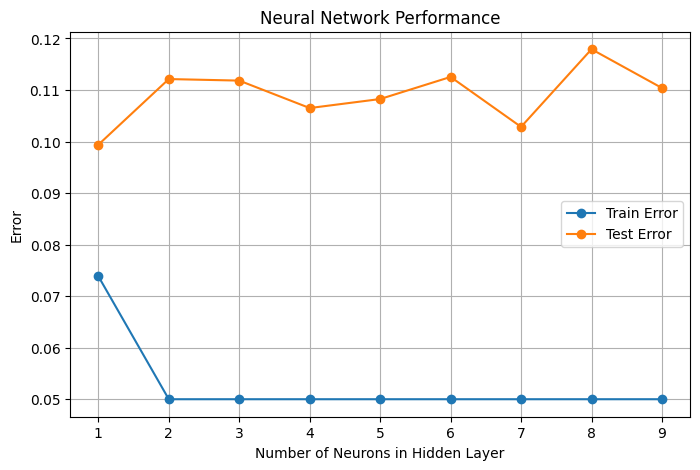

In [8]:
neurons_range = range(1, 10)
plt.figure(figsize=(8,5))
plt.plot(neurons_range, train_errors, label='Train Error', marker='o')
plt.plot(neurons_range, test_errors, label='Test Error', marker='o')
plt.xlabel("Number of Neurons in Hidden Layer")
plt.ylabel("Error")
plt.title("Neural Network Performance")
plt.legend()
plt.grid()
plt.show()

**REPORT**

Q1) What happens if all the weights are initialized to zero (zero initialization)?

If all weights in a neural network are initialized to zero, every neuron in a given layer produces the same output during the forward pass. Consequently, during backpropagation, all neurons receive identical gradients and update in exactly the same way.

This results in symmetry, where neurons fail to learn distinct features. As a result, the network behaves like a single neuron regardless of the number of neurons present, severely limiting its learning capacity.

Q2) What is the difference between epoch, batch, and iteration in neural networks?



* Epoch: One complete pass through the entire training dataset.
* Batch: A subset of the training data used to compute the gradient in one step.
* Iteration: One update of the model’s parameters, typically performed after processing one batch.

Number of iterations per epoch = Total samples / Batch size




Q3) What is the key difference between stochastic gradient descent and batch gradient descent?



* Batch Gradient Descent: Computes the gradient using the entire training dataset before updating the weights. It is stable but computationally expensive and slow for large datasets.
* Stochastic Gradient Descent (SGD): Updates weights using one training example at a time. It is faster and can escape local minima due to its noisy updates but may fluctuate around the optimal solution.



Q4) What problems does a completely random initialization of a neural network lead to?

Completely random initialization, especially with large values, can lead to several issues:

* Vanishing gradients: Activations saturate (e.g., sigmoid), causing gradients to become very small.
* Exploding gradients: Large weights can cause gradients to grow uncontrollably.
* Unstable training: Learning becomes slow or may diverge.

Therefore, controlled initialization methods (e.g., Xavier or He initialization) are preferred to ensure stable and efficient training.

Q5) Name any ten hyperparameters in a multi-layer neural network.

1. Learning rate
2. Number of hidden layers
3. Number of neurons per layer
4. Batch size
5. Number of epochs
6. Activation function
7. Weight initialization method
8. Regularization parameter
9. Dropout rate
10. Optimizer type